In [2]:
# Importing Library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
 
warnings.filterwarnings("ignore")
 
RAW   = "../data/raw"
PROC  = "../data/processed"
os.makedirs(PROC, exist_ok=True)

print("Libraries loaded")

Libraries loaded


In [3]:
# Verifying Dataset and checking ther column :)
# Note for other people: Just run this once :)
 
for fname in os.listdir(RAW):
    if fname.endswith(".csv"):
        path = os.path.join(RAW, fname)
        try:
            df_peek = pd.read_csv(path, nrows=3, encoding="utf-8")
        except UnicodeDecodeError:
            df_peek = pd.read_csv(path, nrows=3, encoding="latin-1")
        print(f"\n{'='*60}")
        print(f"FILE: {fname}")
        print(f"  Shape (3 rows): {df_peek.shape}")
        print(f"  Columns: {df_peek.columns.tolist()}")
        print(df_peek.to_string(index=False))


FILE: Data_Tanaman_Padi_Indonesia_2018-2023_Erlin_New.csv
  Shape (3 rows): (3, 7)
  Columns: ['Province', 'Year', 'Harvested Area', 'Production', 'Rainfall', 'Humidity', 'Temperature']
Province  Year  Harvested Area  Production  Rainfall  Humidity  Temperature
    Aceh  2018          329516     1861567      2336        81           28
    Aceh  2019          310012     1714438      1437        82           27
    Aceh  2020          317869     1757313      1790        76           29

FILE: Produksi Padi Menurut Provinsi (Bulanan), 2025.csv
  Shape (3 rows): (3, 14)
  Columns: ['PROVINSI', 'Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni', 'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember', 'Tahunan']
      PROVINSI   Januari  Februari     Maret     April       Mei      Juni      Juli   Agustus  September   Oktober  November  Desember    Tahunan
          ACEH  71061.29 105254.72 294608.47 281119.38 159158.95  62726.81  12074.69  93899.42  191958.11 225174.64  536

In [4]:
#  LOAD WFP PRICE DATA -> monthly price series
# This is the PRIMARY source for the target variable y (rice price IDR/kg).
 
wfp_path = os.path.join(RAW, "wfp_food_prices_idn.csv")
 
try:
    df_wfp = pd.read_csv(wfp_path, encoding="utf-8")
except UnicodeDecodeError:
    df_wfp = pd.read_csv(wfp_path, encoding="latin-1")
 
print("WFP raw shape:", df_wfp.shape)
print("WFP columns:", df_wfp.columns.tolist())
print(df_wfp.head(3))

WFP raw shape: (213935, 16)
WFP columns: ['date', 'admin1', 'admin2', 'market', 'market_id', 'latitude', 'longitude', 'category', 'commodity', 'commodity_id', 'unit', 'priceflag', 'pricetype', 'currency', 'price', 'usdprice']
         date            admin1 admin2               market    market_id  \
0  2007-01-15  National Average    974   cereals and tubers         Rice   
1  2007-01-15  National Average    974   cereals and tubers  Wheat flour   
2  2007-01-15  National Average    974  meat, fish and eggs         Eggs   

   latitude longitude category commodity commodity_id     unit priceflag  \
0      52.0        KG   actual    Retail          IDR  5941.98      0.65   
1      58.0        KG   actual    Retail          IDR  4328.26      0.48   
2      92.0        KG   actual    Retail          IDR  9150.74         1   

  pricetype currency  price  usdprice  
0       NaN      NaN    NaN       NaN  
1       NaN      NaN    NaN       NaN  
2       NaN      NaN    NaN       NaN  


In [5]:
#INSPECT WFP - admin1 values & commodities
 
print("admin1 unique values:")
print(df_wfp["admin1"].value_counts().head(20))
print("\ncommodity unique values:")
print(df_wfp["commodity"].value_counts().head(20))

admin1 unique values:
admin1
JAWA TENGAH            25407
JAWA TIMUR             19606
JAWA BARAT             19049
SUMATERA UTARA         12183
SULAWESI SELATAN        9906
RIAU                    7904
PAPUA                   7678
KALIMANTAN BARAT        7221
BANTEN                  6419
KALIMANTAN TIMUR        6261
ACEH                    5812
NUSA TENGGARA TIMUR     5137
NUSA TENGGARA BARAT     5074
KEPULAUAN RIAU          4637
BALI                    4416
SUMATERA BARAT          4332
LAMPUNG                 4168
JAMBI                   4138
SULAWESI TENGGARA       4094
PAPUA BARAT             4069
Name: count, dtype: int64

commodity unique values:
commodity
Eggs                          15195
Rice                          11640
Chili (red)                   11464
Meat (chicken, broiler)       11286
Onions (shallot, medium)      10090
Sugar (local)                 10037
Garlic (medium)                9992
Rice (medium quality)          9849
Meat (beef, first quality)     8835
Eggs 

In [6]:
# FILTER WFP for rice, Jawa Timur (with national fallback)
 
# Try Jawa Timur first
df_rice_jatim = df_wfp[
    df_wfp["admin1"].str.contains("Jawa Timur", case=False, na=False) &
    df_wfp["commodity"].str.contains("Rice|Beras", case=False, na=False)
].copy()
 
# Fallback: national average if Jawa Timur not present
if len(df_rice_jatim) < 10:
    print("WARNING: Jawa Timur not found in WFP data — falling back to national average")
    df_rice_jatim = df_wfp[
        df_wfp["commodity"].str.contains("Rice|Beras", case=False, na=False)
    ].copy()
    PRICE_SOURCE_NOTE = "WFP National Average (Jawa Timur not available in this dataset)"
else:
    PRICE_SOURCE_NOTE = "WFP Jawa Timur"
 
print(f"\nUsing: {PRICE_SOURCE_NOTE}")
print(f"Filtered rows: {len(df_rice_jatim)}")
print(df_rice_jatim[["date", "admin1", "commodity", "price"]].head(5))


Using: WFP Jawa Timur
Filtered rows: 2920
            date      admin1              commodity    price
1566  2024-06-15  JAWA TIMUR  Rice (medium quality)  12500.0
1570  2024-06-15  JAWA TIMUR  Rice (medium quality)  13000.0
1579  2024-06-15  JAWA TIMUR  Rice (medium quality)  13750.0
1590  2024-06-15  JAWA TIMUR  Rice (medium quality)  15000.0
1594  2024-06-15  JAWA TIMUR  Rice (medium quality)  13000.0


In [7]:
#WFP — parse dates, resample to monthly
 
df_rice_jatim["date"] = pd.to_datetime(df_rice_jatim["date"], errors="coerce")
df_rice_jatim = df_rice_jatim.dropna(subset=["date", "price"])
df_rice_jatim = df_rice_jatim[df_rice_jatim["price"] > 0]
 
# Resample: monthly mean price
df_price = (
    df_rice_jatim
    .groupby(pd.Grouper(key="date", freq="MS"))["price"]
    .mean()
    .reset_index()
    .rename(columns={"date": "ds", "price": "y"})
    .sort_values("ds")
    .reset_index(drop=True)
)
 
# Sanity checks
print(f"Monthly price rows: {len(df_price)}")
print(f"Date range:  {df_price['ds'].min().date()} → {df_price['ds'].max().date()}")
print(f"Price range: Rp {df_price['y'].min():,.0f} – Rp {df_price['y'].max():,.0f}")
print(df_price.tail(6))
 
assert len(df_price) >= 60, f"Need ≥60 months, got {len(df_price)}"
assert df_price["ds"].min().year <= 2018, "Need data from 2018 or earlier"
print("\n✓ WFP price series OK")

Monthly price rows: 115
Date range:  2016-07-01 → 2026-01-01
Price range: Rp 9,985 – Rp 14,984
            ds             y
109 2025-08-01  14703.125000
110 2025-09-01  14760.714286
111 2025-10-01  14775.000000
112 2025-11-01  14950.000000
113 2025-12-01  14400.000000
114 2026-01-01  14200.000000

✓ WFP price series OK


In [8]:
# LOAD TABEL HARGA (PIHPS) — current price only
# This file has only ~7 days of recent data (April 2026).
# NOT used for training. Used only to get current_price for the dashboard.
 
pihps_path = os.path.join(RAW, "Tabel Harga Berdasarkan Daerah.csv")
 
try:
    df_pihps_raw = pd.read_csv(pihps_path, encoding="utf-8")
except UnicodeDecodeError:
    df_pihps_raw = pd.read_csv(pihps_path, encoding="latin-1")
 
print("PIHPS raw shape:", df_pihps_raw.shape)
print("PIHPS columns:", df_pihps_raw.columns.tolist())
print(df_pihps_raw.head(5))

PIHPS raw shape: (31, 9)
PIHPS columns: ['No', 'Komoditas (Rp)', '20/ 04/ 2026', '21/ 04/ 2026', '22/ 04/ 2026', '23/ 04/ 2026', '24/ 04/ 2026', '27/ 04/ 2026', '28/ 04/ 2026']
  No            Komoditas (Rp) 20/ 04/ 2026 21/ 04/ 2026 22/ 04/ 2026  \
0  I                     Beras       16,200       16,200       16,200   
1  1    Beras Kualitas Bawah I       14,900       14,900       14,950   
2  2   Beras Kualitas Bawah II       15,000       14,850       15,000   
3  3   Beras Kualitas Medium I       16,200       16,300       16,250   
4  4  Beras Kualitas Medium II       15,950       15,900       15,900   

  23/ 04/ 2026 24/ 04/ 2026 27/ 04/ 2026 28/ 04/ 2026  
0       16,200       16,200       16,150       16,150  
1       14,950       14,950       14,900       14,900  
2       14,950       14,950       14,950       14,950  
3       16,200       16,200       16,200       16,200  
4       15,900       15,900       15,900       15,900  


In [9]:
#PIHPS — extract current Beras price
 
# The date columns are everything after the first two (No, Komoditas)
# Identify the commodity column name (may vary)
komoditas_col = df_pihps_raw.columns[1]     # e.g. "Komoditas (Rp)"
date_cols = df_pihps_raw.columns[2:]        # all date columns
 
# Filter for Beras row
beras_mask = df_pihps_raw[komoditas_col].str.contains("Beras", case=False, na=False)
df_beras = df_pihps_raw[beras_mask].copy()
 
if len(df_beras) == 0:
    print("WARNING: Beras row not found in PIHPS — using None")
    CURRENT_PRICE_PIHPS = None
else:
    # Melt wide → long
    df_beras_long = df_beras.melt(
        id_vars=[df_pihps_raw.columns[0], komoditas_col],
        value_vars=date_cols,
        var_name="date_str",
        value_name="price_str"
    )
    # Clean price strings (remove commas, spaces)
    df_beras_long["price"] = (
        df_beras_long["price_str"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace(" ", "", regex=False)
        .str.strip()
    )
    df_beras_long["price"] = pd.to_numeric(df_beras_long["price"], errors="coerce")
    df_beras_long = df_beras_long.dropna(subset=["price"])
    df_beras_long = df_beras_long[df_beras_long["price"] > 0]
 
    # Parse dates — format "DD/ MM/ YYYY" or "DD/MM/YYYY"
    df_beras_long["date_str_clean"] = (
        df_beras_long["date_str"]
        .str.replace(" ", "", regex=False)
    )
    df_beras_long["date"] = pd.to_datetime(
        df_beras_long["date_str_clean"],
        format="%d/%m/%Y",
        errors="coerce"
    )
 
    # Most recent price
    df_beras_long = df_beras_long.sort_values("date")
    CURRENT_PRICE_PIHPS = float(df_beras_long["price"].iloc[-1])
    CURRENT_PRICE_DATE  = df_beras_long["date"].iloc[-1]
 
    print(f"Latest PIHPS Beras price: Rp {CURRENT_PRICE_PIHPS:,.0f}  ({CURRENT_PRICE_DATE.date()})")
    print("\nFull PIHPS price history (all dates found):")
    print(df_beras_long[["date", "price"]].to_string(index=False))
 
# Save current price to a small JSON for the Azure Function to use
import json
current_price_info = {
    "current_price": CURRENT_PRICE_PIHPS,
    "source": "PIHPS Tabel Harga Berdasarkan Daerah",
    "date": str(CURRENT_PRICE_DATE.date()) if CURRENT_PRICE_PIHPS else None
}
with open(os.path.join(PROC, "current_price.json"), "w") as f:
    json.dump(current_price_info, f, indent=2)
print(f"\nSaved: {PROC}/current_price.json")

Latest PIHPS Beras price: Rp 17,400  (2026-04-28)

Full PIHPS price history (all dates found):
      date  price
2026-04-20  16200
2026-04-20  14900
2026-04-20  15000
2026-04-20  16200
2026-04-20  15950
2026-04-20  17450
2026-04-20  17400
2026-04-21  17400
2026-04-21  17500
2026-04-21  16300
2026-04-21  15900
2026-04-21  14900
2026-04-21  16200
2026-04-21  14850
2026-04-22  16200
2026-04-22  14950
2026-04-22  15000
2026-04-22  16250
2026-04-22  15900
2026-04-22  17500
2026-04-22  17400
2026-04-23  17450
2026-04-23  17400
2026-04-23  15900
2026-04-23  16200
2026-04-23  14950
2026-04-23  14950
2026-04-23  16200
2026-04-24  16200
2026-04-24  14950
2026-04-24  14950
2026-04-24  16200
2026-04-24  15900
2026-04-24  17450
2026-04-24  17400
2026-04-27  17400
2026-04-27  17400
2026-04-27  15900
2026-04-27  14900
2026-04-27  14950
2026-04-27  16150
2026-04-27  16200
2026-04-28  17400
2026-04-28  16150
2026-04-28  14900
2026-04-28  14950
2026-04-28  16200
2026-04-28  15900
2026-04-28  17400

Save

In [10]:
# CELL 9: LOAD IEEE DATASET (annual 2018-2023)
# Annual data per province. Used to build harvest-seasonality weighted
# monthly production estimates for 2018–2023.
 
ieee_path = os.path.join(RAW, "Data_Tanaman_Padi_Indonesia_2018-2023_Erlin_New.csv")
 
try:
    df_ieee = pd.read_csv(ieee_path, encoding="utf-8")
except UnicodeDecodeError:
    df_ieee = pd.read_csv(ieee_path, encoding="latin-1")
 
print("IEEE raw shape:", df_ieee.shape)
print("IEEE columns:", df_ieee.columns.tolist())
print(df_ieee.head(3))
print("\nProvinces available:")
print(sorted(df_ieee["Province"].unique()))

IEEE raw shape: (204, 7)
IEEE columns: ['Province', 'Year', 'Harvested Area', 'Production', 'Rainfall', 'Humidity', 'Temperature']
  Province  Year  Harvested Area  Production  Rainfall  Humidity  Temperature
0     Aceh  2018          329516     1861567      2336        81           28
1     Aceh  2019          310012     1714438      1437        82           27
2     Aceh  2020          317869     1757313      1790        76           29

Provinces available:
['Aceh', 'Bali', 'Banten', 'Bengkulu', 'DI Yogyakarta', 'DKI Jakarta', 'Gorontalo', 'Jambi', 'Jawa Barat', 'Jawa Tengah', 'Jawa Timur', 'Kalimantan Barat', 'Kalimantan Selatan', 'Kalimantan Tengah', 'Kalimantan Timur', 'Kalimantan Utara', 'Kepulauan Bangka Belitung', 'Kepulauan Riau', 'Lampung', 'Maluku', 'Maluku Utara', 'Nusa Tenggara Barat', 'Nusa Tenggara Timur', 'Papua', 'Papua Barat', 'Riau', 'Sulawesi Barat', 'Sulawesi Selatan', 'Sulawesi Tengah', 'Sulawesi Tenggara', 'Sulawesi Utara', 'Sumatera Barat', 'Sumatera Selatan', 

In [11]:
#IEEE — filter Jawa Timur, inspect years
 
# Normalize province name variations
df_ieee["Province_norm"] = df_ieee["Province"].str.strip().str.title()
 
jatim_mask = df_ieee["Province_norm"].str.contains(
    "Jawa Timur|East Java", case=False, na=False
)
df_ieee_jatim = df_ieee[jatim_mask].copy()
 
if len(df_ieee_jatim) == 0:
    # Fallback: print all options and pick closest
    print("WARNING: 'Jawa Timur' not found. Available province names:")
    print(df_ieee["Province_norm"].unique())
    raise ValueError("Fix province name above — update the filter string")
 
df_ieee_jatim = df_ieee_jatim.sort_values("Year").reset_index(drop=True)
print(f"Jawa Timur rows: {len(df_ieee_jatim)}")
print(df_ieee_jatim[["Year", "Harvested Area", "Production", "Rainfall"]].to_string(index=False))

Jawa Timur rows: 6
 Year  Harvested Area  Production  Rainfall
 2018         1751192    10203213      2156
 2019         1702426     9580934      1885
 2020         1754380     9944538      2133
 2021         1747481     9789588      2448
 2022         1693211     9526516      3060
 2023         1685560     9591422      2555


In [12]:
# IEEE — expand annual -> monthly using harvest calendar weights
 
# East Java harvest pattern: fraction of annual production per month
# Based on BPS KSA data and known Jawa Timur planting/harvest cycles
HARVEST_WEIGHTS = {
    1:  0.02,   # Jan — tanam / minimal harvest
    2:  0.05,   # Feb — awal panen
    3:  0.15,   # Mar — panen raya dimulai
    4:  0.18,   # Apr — puncak panen raya
    5:  0.12,   # May — akhir panen raya
    6:  0.04,   # Jun — tanam kedua
    7:  0.06,   # Jul — panen kedua dimulai
    8:  0.12,   # Aug — puncak panen kedua
    9:  0.10,   # Sep — akhir panen kedua
    10: 0.07,   # Oct — tanam ketiga/paceklik mulai
    11: 0.05,   # Nov — paceklik
    12: 0.04,   # Dec — paceklik
}
assert abs(sum(HARVEST_WEIGHTS.values()) - 1.0) < 0.001, "Weights must sum to 1"
 
rows = []
for _, annual_row in df_ieee_jatim.iterrows():
    year       = int(annual_row["Year"])
    production = float(annual_row["Production"])
    rainfall   = float(annual_row.get("Rainfall", 0))
 
    for month, weight in HARVEST_WEIGHTS.items():
        rows.append({
            "ds":           pd.Timestamp(year, month, 1),
            "production_est": production * weight,         # monthly estimate (tons GKG)
            "rainfall_annual": rainfall,                   # same for all months in year
        })
 
df_prod_ieee = pd.DataFrame(rows).sort_values("ds").reset_index(drop=True)
print(f"IEEE expanded: {len(df_prod_ieee)} monthly rows (2018–2023)")
print(df_prod_ieee.head(14).to_string(index=False))

IEEE expanded: 72 monthly rows (2018–2023)
        ds  production_est  rainfall_annual
2018-01-01       204064.26           2156.0
2018-02-01       510160.65           2156.0
2018-03-01      1530481.95           2156.0
2018-04-01      1836578.34           2156.0
2018-05-01      1224385.56           2156.0
2018-06-01       408128.52           2156.0
2018-07-01       612192.78           2156.0
2018-08-01      1224385.56           2156.0
2018-09-01      1020321.30           2156.0
2018-10-01       714224.91           2156.0
2018-11-01       510160.65           2156.0
2018-12-01       408128.52           2156.0
2019-01-01       191618.68           1885.0
2019-02-01       479046.70           1885.0


In [13]:
# LOAD BPS BULANAN 2025-2026 (wide -> long)
 
MONTH_MAP = {
    "Januari": 1, "Februari": 2, "Maret": 3, "April": 4,
    "Mei": 5, "Juni": 6, "Juli": 7, "Agustus": 8,
    "September": 9, "Oktober": 10, "November": 11, "Desember": 12
}
MONTH_COLS = list(MONTH_MAP.keys())
 
bps_files = {
    2025: os.path.join(RAW, "Produksi Padi Menurut Provinsi (Bulanan), 2025.csv"),
    2026: os.path.join(RAW, "Produksi Padi Menurut Provinsi (Bulanan), 2026.csv"),
}
 
bps_rows = []
for year, fpath in bps_files.items():
    if not os.path.exists(fpath):
        print(f"WARNING: {fpath} not found — skipping {year}")
        continue
 
    try:
        df_bps = pd.read_csv(fpath, encoding="utf-8")
    except UnicodeDecodeError:
        df_bps = pd.read_csv(fpath, encoding="latin-1")
 
    print(f"\nBPS {year} columns: {df_bps.columns.tolist()}")
    print(df_bps.head(3))
 
    # Identify province column (first column)
    prov_col = df_bps.columns[0]
 
    # Melt month columns → long
    available_months = [m for m in MONTH_COLS if m in df_bps.columns]
    df_melt = df_bps.melt(
        id_vars=[prov_col],
        value_vars=available_months,
        var_name="month_name",
        value_name="production_ton"
    )
 
    df_melt["Year"]  = year
    df_melt["month"] = df_melt["month_name"].map(MONTH_MAP)
    df_melt["province_norm"] = df_melt[prov_col].str.strip().str.title()
 
    # Filter Jawa Timur
    jatim = df_melt[
        df_melt["province_norm"].str.contains("Jawa Timur", case=False, na=False)
    ].copy()
 
    if len(jatim) == 0:
        print(f"WARNING: Jawa Timur not found in BPS {year}")
        print("Available provinces:", df_melt["province_norm"].unique()[:10])
    else:
        # Clean production values
        jatim["production_ton"] = pd.to_numeric(
            jatim["production_ton"].astype(str).str.replace(",", "", regex=False),
            errors="coerce"
        )
        jatim = jatim.dropna(subset=["production_ton"])
        jatim = jatim[jatim["production_ton"] > 0]
        bps_rows.append(jatim[["Year", "month", "production_ton"]])
        print(f"  Jawa Timur rows for {year}: {len(jatim)}")
 
if bps_rows:
    df_prod_bps = pd.concat(bps_rows, ignore_index=True)
    df_prod_bps["ds"] = pd.to_datetime(
        df_prod_bps["Year"].astype(str) + "-" +
        df_prod_bps["month"].astype(str).str.zfill(2) + "-01"
    )
    df_prod_bps = df_prod_bps[["ds", "production_ton"]].rename(
        columns={"production_ton": "production_est"}
    ).sort_values("ds").reset_index(drop=True)
    print(f"\nBPS bulanan combined: {len(df_prod_bps)} rows")
    print(df_prod_bps)
else:
    df_prod_bps = pd.DataFrame(columns=["ds", "production_est"])
    print("WARNING: No BPS bulanan data loaded")


BPS 2025 columns: ['PROVINSI', 'Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni', 'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember', 'Tahunan']
         PROVINSI    Januari   Februari      Maret      April        Mei  \
0            ACEH   71061.29  105254.72  294608.47  281119.38  159158.95   
1  SUMATERA UTARA  194014.90  404718.92  314988.21  179663.78  199994.75   
2  SUMATERA BARAT  141426.58  157807.91  162064.93   98223.19  109132.17   

        Juni       Juli    Agustus  September    Oktober   November  \
0   62726.81   12074.69   93899.42  191958.11  225174.64   53601.03   
1  246094.52  173992.50  277021.17  346982.65  200960.40  109865.22   
2  131014.43   92412.45   85163.51  150659.50   95787.41   67092.35   

    Desember     Tahunan  
0   64562.57  1615200.08  
1  104358.33  2752655.35  
2   91912.25  1382696.68  
  Jawa Timur rows for 2025: 12

BPS 2026 columns: ['PROVINSI', 'Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni', 'Juli', 'Agustus'

In [14]:
# COMBINE PRODUCTION — IEEE (2018-2023) + BPS (2025-2026)
# Stack both sources. Note: 2024 is a gap — we'll fill with interpolation.
 
df_prod_ieee_slim = df_prod_ieee[["ds", "production_est"]].copy()
 
df_prod_all = pd.concat([df_prod_ieee_slim, df_prod_bps], ignore_index=True)
df_prod_all = df_prod_all.sort_values("ds").drop_duplicates("ds").reset_index(drop=True)
 
print(f"Combined production rows: {len(df_prod_all)}")
print(f"Date range: {df_prod_all['ds'].min().date()} → {df_prod_all['ds'].max().date()}")
 
# Check for 2024 gap
prod_2024 = df_prod_all[df_prod_all["ds"].dt.year == 2024]
print(f"\n2024 production rows: {len(prod_2024)}")
if len(prod_2024) == 0:
    print("  → 2024 gap will be filled by forward-fill + harvest weight interpolation")

Combined production rows: 89
Date range: 2018-01-01 → 2026-05-01

2024 production rows: 0
  → 2024 gap will be filled by forward-fill + harvest weight interpolation


In [15]:
# FILL 2024 GAP — interpolate using 5-year average weights
 
# Build the full monthly date spine for the entire training range
date_spine = pd.date_range(
    start=df_price["ds"].min(),
    end=df_price["ds"].max(),
    freq="MS"
)
df_prod_full = pd.DataFrame({"ds": date_spine})
df_prod_full = df_prod_full.merge(df_prod_all, on="ds", how="left")
 
# For months where production is missing (2024 gap):
# Use 5-year monthly average production (from 2018-2023) scaled by harvest weights
annual_avg_jatim = df_ieee_jatim["Production"].mean()  # 5-year annual average
 
fill_mask = df_prod_full["production_est"].isna()
if fill_mask.sum() > 0:
    df_prod_full.loc[fill_mask, "production_est"] = df_prod_full.loc[fill_mask, "ds"].dt.month.map(
        lambda m: annual_avg_jatim * HARVEST_WEIGHTS.get(m, 0.05)
    )
    n_filled = fill_mask.sum()
    print(f"Filled {n_filled} missing months (2024 gap) using 5-yr harvest weight average")
 
print(f"\nProduction spine: {len(df_prod_full)} rows, 0 NaN: {df_prod_full['production_est'].isna().sum()}")

Filled 30 missing months (2024 gap) using 5-yr harvest weight average

Production spine: 115 rows, 0 NaN: 0


In [16]:
# BUILD PRODUCTION DEVIATION FEATURE
# Key TraderEdge feature: deviation from 5-year seasonal mean.
# Values > 0 = above-normal supply → glut signal
# Values < 0 = below-normal supply → shortage signal
 
# Compute 5-year monthly mean (from 2018-2022, pre-2023 data only to avoid leakage)
df_prod_base = df_prod_full[df_prod_full["ds"].dt.year <= 2022].copy()
seasonal_mean = (
    df_prod_base.groupby(df_prod_base["ds"].dt.month)["production_est"]
    .mean()
    .rename("prod_seasonal_mean")
)
df_prod_full["month"] = df_prod_full["ds"].dt.month
df_prod_full = df_prod_full.merge(seasonal_mean, left_on="month", right_index=True, how="left")
df_prod_full["production_dev_pct"] = (
    (df_prod_full["production_est"] - df_prod_full["prod_seasonal_mean"])
    / df_prod_full["prod_seasonal_mean"]
)
 
print("Production deviation feature sample:")
print(df_prod_full[["ds", "production_est", "prod_seasonal_mean", "production_dev_pct"]].head(14).to_string(index=False))
print(f"\nproduction_dev_pct range: {df_prod_full['production_dev_pct'].min():.2f} → {df_prod_full['production_dev_pct'].max():.2f}")

Production deviation feature sample:
        ds  production_est  prod_seasonal_mean  production_dev_pct
2016-07-01    5.863621e+05        5.879159e+05           -0.002643
2016-08-01    1.172724e+06        1.175832e+06           -0.002643
2016-09-01    9.772702e+05        9.798599e+05           -0.002643
2016-10-01    6.840891e+05        6.859019e+05           -0.002643
2016-11-01    4.886351e+05        4.899299e+05           -0.002643
2016-12-01    3.909081e+05        3.919440e+05           -0.002643
2017-01-01    1.954540e+05        1.960583e+05           -0.003082
2017-02-01    4.886351e+05        4.901458e+05           -0.003082
2017-03-01    1.465905e+06        1.470437e+06           -0.003082
2017-04-01    1.759086e+06        1.764525e+06           -0.003082
2017-05-01    1.172724e+06        1.176350e+06           -0.003082
2017-06-01    3.909081e+05        3.921166e+05           -0.003082
2017-07-01    5.863621e+05        5.879159e+05           -0.002643
2017-08-01    1.172724e+0

In [17]:
# BUILD RAINFALL DEVIATION FEATURE (from IEEE)
# IEEE dataset has annual rainfall per province.
# We'll distribute it to monthly using seasonal pattern, same as production.
 
# East Java monthly rainfall distribution (fraction of annual total)
RAINFALL_WEIGHTS = {
    1: 0.14, 2: 0.13, 3: 0.12, 4: 0.09,
    5: 0.06, 6: 0.04, 7: 0.02, 8: 0.02,
    9: 0.04, 10: 0.08, 11: 0.12, 12: 0.14
}
assert abs(sum(RAINFALL_WEIGHTS.values()) - 1.0) < 0.001
 
rain_rows = []
for _, row in df_ieee_jatim.iterrows():
    year    = int(row["Year"])
    rainfall = float(row.get("Rainfall", 0))
    for month, weight in RAINFALL_WEIGHTS.items():
        rain_rows.append({
            "ds": pd.Timestamp(year, month, 1),
            "rainfall_mm": rainfall * weight
        })
 
df_rain = pd.DataFrame(rain_rows).sort_values("ds").reset_index(drop=True)
 
# Compute rainfall deviation from monthly normal
rain_seasonal_mean = (
    df_rain.groupby(df_rain["ds"].dt.month)["rainfall_mm"]
    .mean()
    .rename("rain_seasonal_mean")
)
df_rain["month"] = df_rain["ds"].dt.month
df_rain = df_rain.merge(rain_seasonal_mean, left_on="month", right_index=True, how="left")
df_rain["rainfall_dev_pct"] = (
    (df_rain["rainfall_mm"] - df_rain["rain_seasonal_mean"])
    / df_rain["rain_seasonal_mean"]
)
 
print("Rainfall deviation feature:")
print(df_rain[["ds", "rainfall_mm", "rainfall_dev_pct"]].head(14).to_string(index=False))

Rainfall deviation feature:
        ds  rainfall_mm  rainfall_dev_pct
2018-01-01       301.84         -0.091382
2018-02-01       280.28         -0.091382
2018-03-01       258.72         -0.091382
2018-04-01       194.04         -0.091382
2018-05-01       129.36         -0.091382
2018-06-01        86.24         -0.091382
2018-07-01        43.12         -0.091382
2018-08-01        43.12         -0.091382
2018-09-01        86.24         -0.091382
2018-10-01       172.48         -0.091382
2018-11-01       258.72         -0.091382
2018-12-01       301.84         -0.091382
2019-01-01       263.90         -0.205591
2019-02-01       245.05         -0.205591


In [18]:
# %% ─── CELL 17: BUILD HARVEST CALENDAR FEATURES ────────────────────────────
# No external file needed — derived from known East Java harvest calendar.
 
def build_harvest_features(ds_series: pd.Series) -> pd.DataFrame:
    df = pd.DataFrame({"ds": ds_series})
    month = df["ds"].dt.month
 
    # Binary flags
    df["harvest_window"] = month.isin([3, 4, 5, 7, 8, 9]).astype(int)
    df["lean_season"]    = month.isin([10, 11, 12, 1, 2]).astype(int)
 
    # Countdown: days until next harvest window start (March=3, July=7)
    HARVEST_STARTS = [3, 7]
    def days_to_next(date):
        candidates = []
        for m in HARVEST_STARTS:
            for y in [date.year, date.year + 1]:
                target = pd.Timestamp(y, m, 1)
                if target > date:
                    candidates.append((target - date).days)
        return min(candidates)
 
    df["harvest_proximity_days"] = df["ds"].apply(days_to_next)
    return df[["ds", "harvest_window", "lean_season", "harvest_proximity_days"]]
 
df_harvest = build_harvest_features(date_spine)
print("Harvest calendar features:")
print(df_harvest.head(14).to_string(index=False))

Harvest calendar features:
        ds  harvest_window  lean_season  harvest_proximity_days
2016-07-01               1            0                     243
2016-08-01               1            0                     212
2016-09-01               1            0                     181
2016-10-01               0            1                     151
2016-11-01               0            1                     120
2016-12-01               0            1                      90
2017-01-01               0            1                      59
2017-02-01               0            1                      28
2017-03-01               1            0                     122
2017-04-01               1            0                      91
2017-05-01               1            0                      61
2017-06-01               0            0                      30
2017-07-01               1            0                     243
2017-08-01               1            0                     212


In [19]:
# BUILD PRICE MOMENTUM FEATURES
# These are derived from the price series itself — no external data needed.
# Captures whether prices are rising, falling, or accelerating.
 
df_price_mom = df_price.sort_values("ds").copy()
df_price_mom["price_mom_1m"] = df_price_mom["y"].pct_change(periods=1)
df_price_mom["price_mom_3m"] = df_price_mom["y"].pct_change(periods=3)
df_price_mom["price_accel"]  = df_price_mom["price_mom_1m"] - df_price_mom["price_mom_3m"]
 
print("Price momentum features:")
print(df_price_mom[["ds", "y", "price_mom_1m", "price_mom_3m", "price_accel"]].tail(10).to_string(index=False))

Price momentum features:
        ds            y  price_mom_1m  price_mom_3m  price_accel
2025-04-01 13929.166667      0.010668     -0.000777     0.011445
2025-05-01 13600.000000     -0.023631     -0.027877     0.004246
2025-06-01 14221.875000      0.045726      0.031906     0.013820
2025-07-01 14585.714286      0.025583      0.047135    -0.021552
2025-08-01 14703.125000      0.008050      0.081112    -0.073062
2025-09-01 14760.714286      0.003917      0.037888    -0.033971
2025-10-01 14775.000000      0.000968      0.012977    -0.012010
2025-11-01 14950.000000      0.011844      0.016791    -0.004946
2025-12-01 14400.000000     -0.036789     -0.024437    -0.012352
2026-01-01 14200.000000     -0.013889     -0.038917     0.025028


In [20]:
# MERGE ALL INTO MASTER_DF
# Left join on ds (monthly date). Price series is the backbone.
 
master = df_price_mom[["ds", "y", "price_mom_3m", "price_accel"]].copy()
 
# 1. Production deviation
master = master.merge(
    df_prod_full[["ds", "production_dev_pct"]],
    on="ds", how="left"
)
 
# 2. Rainfall deviation
master = master.merge(
    df_rain[["ds", "rainfall_dev_pct"]],
    on="ds", how="left"
)
 
# 3. Harvest calendar features
master = master.merge(df_harvest, on="ds", how="left")
 
print(f"\nMerge complete. Shape: {master.shape}")
print(f"Columns: {master.columns.tolist()}")


Merge complete. Shape: (115, 9)
Columns: ['ds', 'y', 'price_mom_3m', 'price_accel', 'production_dev_pct', 'rainfall_dev_pct', 'harvest_window', 'lean_season', 'harvest_proximity_days']


In [21]:
# HANDLE MISSING VALUES
print("Missing values before fill:")
print(master.isna().sum())
 
# Production: fill remaining gaps with 0 (neutral = no deviation from mean)
n_prod_na = master["production_dev_pct"].isna().sum()
master["production_dev_pct"] = master["production_dev_pct"].fillna(0.0)
if n_prod_na > 0:
    print(f"\nFilled {n_prod_na} production_dev_pct NaN → 0.0 (neutral)")
 
# Rainfall: fill gaps with 0 (neutral)
n_rain_na = master["rainfall_dev_pct"].isna().sum()
master["rainfall_dev_pct"] = master["rainfall_dev_pct"].fillna(0.0)
if n_rain_na > 0:
    print(f"Filled {n_rain_na} rainfall_dev_pct NaN → 0.0 (neutral)")
 
# Drop first 3 rows — NaN in momentum cols due to pct_change lookback
master = master.dropna(subset=["price_mom_3m", "price_accel", "y"])
master = master.reset_index(drop=True)
 
print("\nMissing values after fill:")
print(master.isna().sum())

Missing values before fill:
ds                         0
y                         35
price_mom_3m               3
price_accel                3
production_dev_pct         0
rainfall_dev_pct          43
harvest_window             0
lean_season                0
harvest_proximity_days     0
dtype: int64
Filled 43 rainfall_dev_pct NaN → 0.0 (neutral)

Missing values after fill:
ds                        0
y                         0
price_mom_3m              0
price_accel               0
production_dev_pct        0
rainfall_dev_pct          0
harvest_window            0
lean_season               0
harvest_proximity_days    0
dtype: int64


In [22]:
# FINAL VALIDATION
 
REQUIRED_COLS = [
    "ds", "y", "production_dev_pct", "price_mom_3m",
    "price_accel", "harvest_window", "lean_season",
    "harvest_proximity_days", "rainfall_dev_pct"
]
 
missing_cols = [c for c in REQUIRED_COLS if c not in master.columns]
assert not missing_cols, f"Missing columns: {missing_cols}"
assert master["y"].notna().all(),          "Null values in y"
assert master["ds"].is_monotonic_increasing, "ds not sorted"
assert master["harvest_window"].isin([0, 1]).all(), "harvest_window must be 0/1"
assert len(master) >= 60,                 f"Need ≥60 rows, got {len(master)}"
assert master["y"].mean() > 5000,         f"Price seems too low: {master['y'].mean():.0f}"
assert master["y"].mean() < 30000,        f"Price seems too high: {master['y'].mean():.0f}"
 
print("✓ All validation checks passed")
print(f"\nmaster_df summary:")
print(f"  Shape:       {master.shape}")
print(f"  Date range:  {master['ds'].min().date()} → {master['ds'].max().date()}")
print(f"  Avg price:   Rp {master['y'].mean():,.0f}/kg")
print(f"  Prod dev:    {master['production_dev_pct'].min():.2f} → {master['production_dev_pct'].max():.2f}")
print(f"  Rain dev:    {master['rainfall_dev_pct'].min():.2f} → {master['rainfall_dev_pct'].max():.2f}")
 
print("\nFull master_df tail:")
print(master.tail(8).to_string(index=False))

✓ All validation checks passed

master_df summary:
  Shape:       (77, 9)
  Date range:  2016-10-01 → 2026-01-01
  Avg price:   Rp 12,050/kg
  Prod dev:    -0.41 → 1.45
  Rain dev:    -0.10 → 0.29

Full master_df tail:
        ds            y  price_mom_3m  price_accel  production_dev_pct  rainfall_dev_pct  harvest_window  lean_season  harvest_proximity_days
2025-06-01 14221.875000      0.031906     0.013820            0.986874               0.0               0            0                      30
2025-07-01 14585.714286      0.047135    -0.021552            0.722020               0.0               1            0                     243
2025-08-01 14703.125000      0.081112    -0.073062           -0.298600               0.0               1            0                     212
2025-09-01 14760.714286      0.037888    -0.033971           -0.329328               0.0               1            0                     181
2025-10-01 14775.000000      0.012977    -0.012010           -0.141395 

In [25]:
# CELL 22: SAVE OUTPUTS 
 
# Full master
master.to_csv(os.path.join(PROC, "master_df.csv"), index=False)
print(f"Saved: {PROC}/master_df.csv  ({len(master)} rows)")
 
# Train / holdout split
HOLDOUT_START = "2024-01-01"
train   = master[master["ds"] < HOLDOUT_START].reset_index(drop=True)
holdout = master[master["ds"] >= HOLDOUT_START].reset_index(drop=True)
 
train.to_csv(os.path.join(PROC, "train_df.csv"), index=False)
holdout.to_csv(os.path.join(PROC, "holdout_df.csv"), index=False)
 
print(f"Saved: {PROC}/train_df.csv    ({len(train)} rows, up to {train['ds'].max().date()})")
print(f"Saved: {PROC}/holdout_df.csv  ({len(holdout)} rows, from {holdout['ds'].min().date() if len(holdout) > 0 else 'n/a'})")
 
# Sample (safe to share/commit)
os.makedirs("../data/sample", exist_ok=True)
master.tail(12).to_csv("../data/sample/sample_12rows.csv", index=False)
print(f"Saved: data/sample/sample_12rows.csv")

Saved: ../data/processed/master_df.csv  (77 rows)
Saved: ../data/processed/train_df.csv    (52 rows, up to 2023-12-01)
Saved: ../data/processed/holdout_df.csv  (25 rows, from 2024-01-01)
Saved: data/sample/sample_12rows.csv


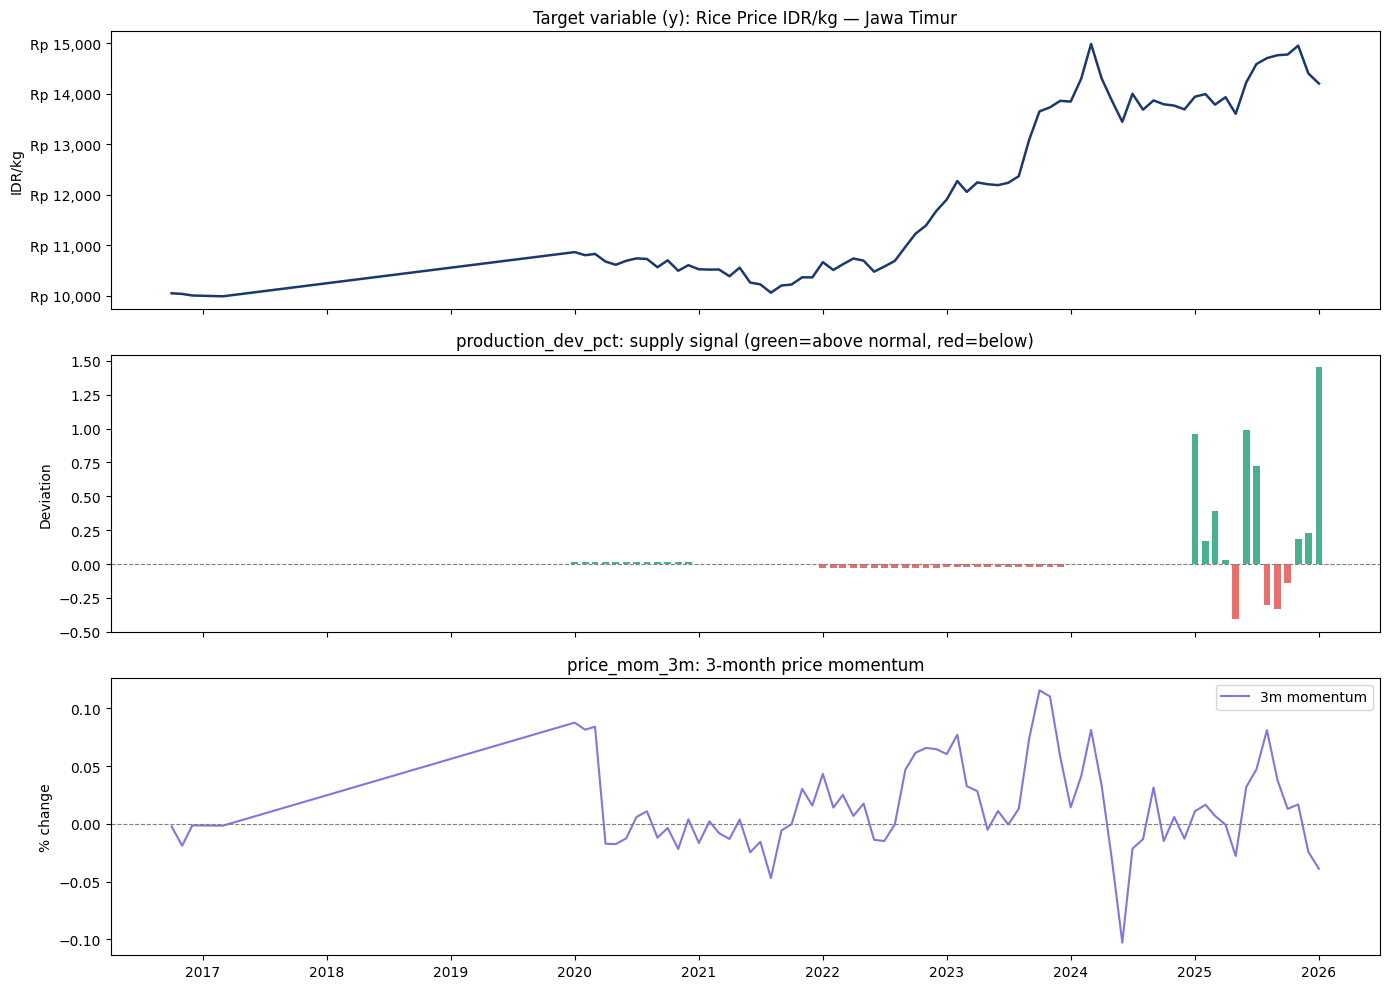

Plot saved: master_df_visual_check.png

✓ DATA PIPELINE COMPLETE — ready for notebook 02 (model training)


In [24]:
# QUICK VISUAL CHECK
# Sanity plot — run this to visually inspect the data before modeling.
 
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
 
# Price
axes[0].plot(master["ds"], master["y"], color="#1B3A6B", linewidth=1.8)
axes[0].set_title("Target variable (y): Rice Price IDR/kg — Jawa Timur", fontsize=12)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"Rp {x:,.0f}"))
axes[0].set_ylabel("IDR/kg")
 
# Production deviation
axes[1].bar(master["ds"], master["production_dev_pct"],
            color=["#1D9E75" if v >= 0 else "#E24B4A" for v in master["production_dev_pct"]],
            width=20, alpha=0.8)
axes[1].axhline(0, color="gray", linewidth=0.8, linestyle="--")
axes[1].set_title("production_dev_pct: supply signal (green=above normal, red=below)", fontsize=12)
axes[1].set_ylabel("Deviation")
 
# Price momentum
axes[2].plot(master["ds"], master["price_mom_3m"], color="#7F77DD", linewidth=1.5, label="3m momentum")
axes[2].axhline(0, color="gray", linewidth=0.8, linestyle="--")
axes[2].set_title("price_mom_3m: 3-month price momentum", fontsize=12)
axes[2].set_ylabel("% change")
axes[2].legend()
 
plt.tight_layout()
plt.savefig(os.path.join(PROC, "master_df_visual_check.png"), dpi=130, bbox_inches="tight")
plt.show()
print("Plot saved: master_df_visual_check.png")
print("\n✓ DATA PIPELINE COMPLETE — ready for notebook 02 (model training)")